Install libraries

In [1]:


# TensorFlow -> CNN and deep learning
# OpenCV -> image processing
# scikit-image -> HOG, LBP and GLCM
# scikit-learn -> data splitting and evaluation
# matplotlib -> visualization
# pandas/numpy -> data handling

!pip -q install tensorflow opencv-python scikit-image scikit-learn matplotlib pandas numpy

Import Libraries

In [2]:

# Basic data handling
import os
import random
import numpy as np
import pandas as pd

# Image processing
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt

# HOG, LBP and GLCM feature extraction
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# TensorFlow / Keras for CNN
import tensorflow as tf
from tensorflow.keras import layers, models

# Check TensorFlow version
print("TensorFlow version:", tf.__version__)

print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


Download and Load the Chest X-Ray Dataset

In [3]:


import os
import zipfile
import requests

# Dataset download URL
url = "https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/chest-xray-pneumonia"

# File name for the downloaded ZIP
zip_file = "/content/chest_xray.zip"

print("Downloading Chest X-Ray dataset...")

# Download the ZIP file
response = requests.get(url)

# Check whether the download was successful
print("Download status:", response.status_code)

# Save the downloaded file
with open(zip_file, "wb") as file:
    file.write(response.content)

# Check the downloaded file size
file_size = os.path.getsize(zip_file) / (1024 * 1024)

print("Downloaded file size:", round(file_size, 2), "MB")

# --------------------------------------------
# Check whether the downloaded file is a ZIP
# --------------------------------------------

if not zipfile.is_zipfile(zip_file):
    raise ValueError(
        "Downloaded file is not a valid ZIP file. "
        "Please run this cell again."
    )

# --------------------------------------------
# Extract the dataset
# --------------------------------------------

print("Extracting dataset...")

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/chest_xray_data")

print("Dataset extracted successfully!")

# --------------------------------------------
# Find the dataset directory
# --------------------------------------------

print("\nDataset folders:")

for root, dirs, files in os.walk("/content/chest_xray_data"):
    level = root.replace("/content/chest_xray_data", "").count(os.sep)

    if level <= 2:
        print(root)

Download status: 200
Downloaded file size: 2349.25 MB
Extracting dataset...
Dataset extracted successfully!

Dataset folders:
/content/chest_xray_data
/content/chest_xray_data/chest_xray
/content/chest_xray_data/chest_xray/chest_xray
/content/chest_xray_data/chest_xray/train
/content/chest_xray_data/chest_xray/__MACOSX
/content/chest_xray_data/chest_xray/test
/content/chest_xray_data/chest_xray/val


Explore Dataset + Class Balance

========== CLASS DISTRIBUTION ==========
Normal images    : 1341
Pneumonia images: 3875
Total images    : 5216


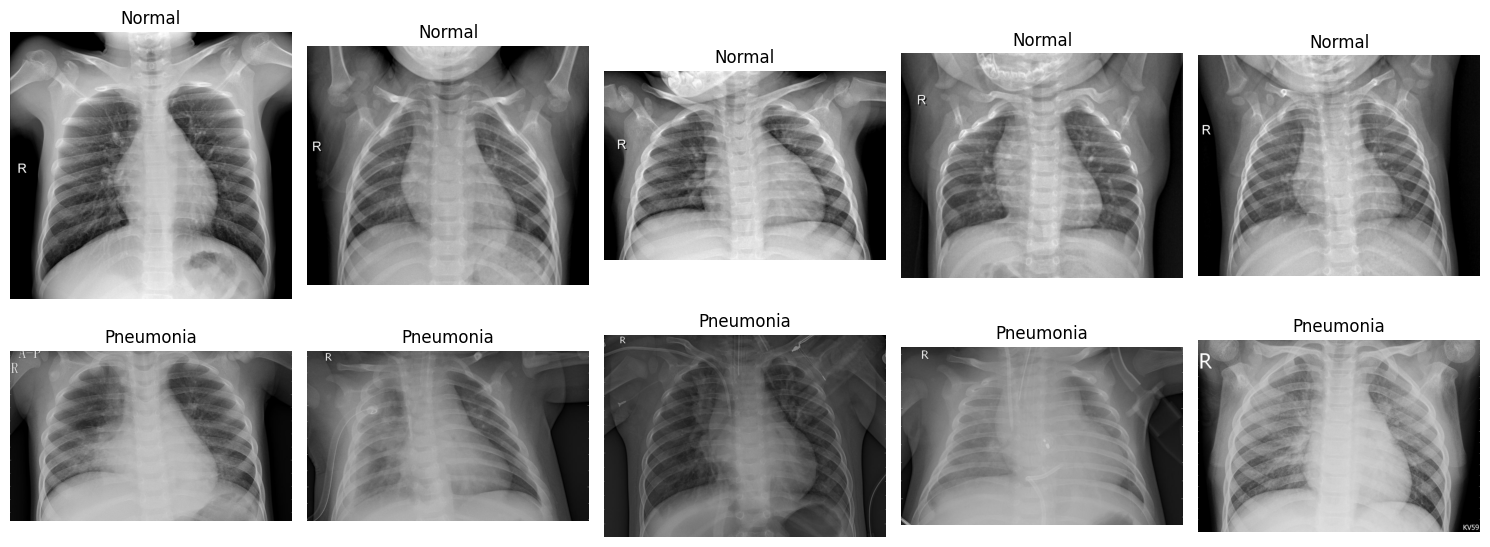

In [4]:


# Path where the dataset was extracted
dataset_path = "/content/chest_xray_data/chest_xray"

# Define paths for training data
train_path = os.path.join(dataset_path, "train")

# Class folders
normal_path = os.path.join(train_path, "NORMAL")
pneumonia_path = os.path.join(train_path, "PNEUMONIA")

# --------------------------------------------
# Count images in each class
# --------------------------------------------

normal_images = [
    file for file in os.listdir(normal_path)
    if file.lower().endswith((".jpeg", ".jpg", ".png"))
]

pneumonia_images = [
    file for file in os.listdir(pneumonia_path)
    if file.lower().endswith((".jpeg", ".jpg", ".png"))
]

print("========== CLASS DISTRIBUTION ==========")
print("Normal images    :", len(normal_images))
print("Pneumonia images:", len(pneumonia_images))
print("Total images    :", len(normal_images) + len(pneumonia_images))

# --------------------------------------------
# Display 5 random images from each class
# --------------------------------------------

random.seed(42)

normal_samples = random.sample(
    normal_images,
    min(5, len(normal_images))
)

pneumonia_samples = random.sample(
    pneumonia_images,
    min(5, len(pneumonia_images))
)

# Create figure
plt.figure(figsize=(15, 6))

# Display Normal images
for i, filename in enumerate(normal_samples):

    image_path = os.path.join(normal_path, filename)

    image = cv2.imread(image_path)

    # Convert BGR to RGB for matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title("Normal")
    plt.axis("off")

# Display Pneumonia images
for i, filename in enumerate(pneumonia_samples):

    image_path = os.path.join(pneumonia_path, filename)

    image = cv2.imread(image_path)

    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 6)
    plt.imshow(image, cmap="gray")
    plt.title("Pneumonia")
    plt.axis("off")

plt.tight_layout()
plt.show()

Preprocessing + HOG + LBP + GLCM

In [5]:
# ============================================
# CELL 5: IMAGE PREPROCESSING AND FEATURE EXTRACTION
# ============================================

from skimage.feature import (
    hog,
    local_binary_pattern,
    graycomatrix,
    graycoprops
)

# --------------------------------------------
# Settings
# --------------------------------------------

# All X-ray images will be resized to 128 x 128
IMG_SIZE = (128, 128)

# Maximum number of images used for feature extraction
# This keeps the Colab runtime manageable.
MAX_IMAGES_PER_CLASS = 1000

# --------------------------------------------
# Function to extract HOG, LBP and GLCM
# features from one image
# --------------------------------------------

def extract_features(image_path):

    # Read image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Resize image to fixed dimensions
    image = cv2.resize(image, IMG_SIZE)

    # Normalize pixel values between 0 and 1
    image_normalized = image / 255.0

    # ----------------------------------------
    # HOG FEATURES
    # ----------------------------------------

    # HOG captures edges and shape information
    hog_features = hog(
        image_normalized,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    # ----------------------------------------
    # LBP FEATURES
    # ----------------------------------------

    # LBP captures local texture information
    radius = 1
    points = 8 * radius

    lbp = local_binary_pattern(
        image,
        points,
        radius,
        method="uniform"
    )

    # Calculate LBP histogram
    n_bins = points + 2

    lbp_histogram, _ = np.histogram(
        lbp.ravel(),
        bins=n_bins,
        range=(0, n_bins),
        density=True
    )

    # ----------------------------------------
    # GLCM FEATURES
    # ----------------------------------------

    # Convert image to 8-bit grayscale levels
    image_8bit = (image / 32).astype(np.uint8)

    # Create Gray-Level Co-occurrence Matrix
    glcm = graycomatrix(
        image_8bit,
        distances=[1],
        angles=[0],
        levels=8,
        symmetric=True,
        normed=True
    )

    # Extract important GLCM properties
    glcm_features = [
        graycoprops(glcm, "contrast")[0, 0],
        graycoprops(glcm, "dissimilarity")[0, 0],
        graycoprops(glcm, "homogeneity")[0, 0],
        graycoprops(glcm, "energy")[0, 0],
        graycoprops(glcm, "correlation")[0, 0]
    ]

    # Combine all extracted features
    feature_vector = np.concatenate([
        hog_features,
        lbp_histogram,
        glcm_features
    ])

    return feature_vector


# ============================================
# LOAD IMAGE PATHS
# ============================================

image_paths = []
labels = []

# Get Normal images
normal_files = [
    f for f in os.listdir(normal_path)
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
]

# Get Pneumonia images
pneumonia_files = [
    f for f in os.listdir(pneumonia_path)
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
]

# Limit the number of images for faster processing
normal_files = normal_files[:MAX_IMAGES_PER_CLASS]
pneumonia_files = pneumonia_files[:MAX_IMAGES_PER_CLASS]

# Store image paths and labels
for file in normal_files:
    image_paths.append(os.path.join(normal_path, file))
    labels.append(0)          # 0 = Normal

for file in pneumonia_files:
    image_paths.append(os.path.join(pneumonia_path, file))
    labels.append(1)          # 1 = Pneumonia

print("Total images selected:", len(image_paths))
print("Normal:", labels.count(0))
print("Pneumonia:", labels.count(1))


# ============================================
# EXTRACT FEATURES
# ============================================

features = []

print("\nExtracting HOG, LBP and GLCM features...")

for i, image_path in enumerate(image_paths):

    try:
        feature_vector = extract_features(image_path)
        features.append(feature_vector)

    except Exception as e:
        print("Error processing:", image_path)
        print("Reason:", e)

# Convert features into NumPy array
X_features = np.array(features)

# Convert labels into NumPy array
y_features = np.array(labels[:len(X_features)])

print("\nFeature extraction completed!")

print("Feature matrix shape:", X_features.shape)
print("Label array shape:", y_features.shape)

Total images selected: 2000
Normal: 1000
Pneumonia: 1000

Extracting HOG, LBP and GLCM features...

Feature extraction completed!
Feature matrix shape: (2000, 1779)
Label array shape: (2000,)


Train / Validation / Test Split

In [6]:

# First split:
# 70% Training + 30% Temporary data

X_train, X_temp, y_train, y_temp = train_test_split(
    X_features,
    y_features,
    test_size=0.30,
    random_state=42,
    stratify=y_features
)


# Second split:
# Divide the remaining 30% equally
# into 15% Validation + 15% Testing


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


# Display the split sizes


print("========== DATASET SPLIT ==========")

print("Training data  :", X_train.shape[0])
print("Validation data:", X_val.shape[0])
print("Testing data   :", X_test.shape[0])

# Calculate percentages
total = len(X_features)

print("\n========== PERCENTAGES ==========")
print("Training   :", round(len(X_train) / total * 100, 2), "%")
print("Validation :", round(len(X_val) / total * 100, 2), "%")
print("Testing    :", round(len(X_test) / total * 100, 2), "%")

========== DATASET SPLIT ==========
Training data  : 1400
Validation data: 300
Testing data   : 300

========== PERCENTAGES ==========
Training   : 70.0 %
Validation : 15.0 %
Testing    : 15.0 %


Prepare Images for CNN

In [7]:


# Image dimensions required by the assignment
IMG_HEIGHT = 128
IMG_WIDTH = 128

# Function to load and preprocess images

def load_images(image_paths, labels):
    """
    Loads X-ray images, converts them to grayscale,
    resizes them to 128x128, and normalizes pixels.
    """

    images = []
    valid_labels = []

    for image_path, label in zip(image_paths, labels):

        # Read image as grayscale
        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Skip image if it could not be loaded
        if image is None:
            continue

        # Resize image to 128 x 128
        image = cv2.resize(
            image,
            (IMG_WIDTH, IMG_HEIGHT)
        )

        # Normalize pixel values from 0-255 to 0-1
        image = image.astype("float32") / 255.0

        images.append(image)
        valid_labels.append(label)

    # Convert to NumPy arrays
    images = np.array(images)
    labels = np.array(valid_labels)

    # Add channel dimension for CNN
    # Shape becomes: (samples, 128, 128, 1)
    images = images.reshape(
        -1,
        IMG_HEIGHT,
        IMG_WIDTH,
        1
    )

    return images, labels


# LOAD ALL SELECTED IMAGE PATHS

# We use the same images selected during
# HOG/LBP/GLCM feature extraction.

X_images, y_images = load_images(
    image_paths,
    labels
)

print("CNN image data loaded successfully!")
print("Image data shape:", X_images.shape)
print("Label shape:", y_images.shape)



# SPLIT IMAGES INTO 70/15/15


# First split:
# 70% training + 30% temporary
X_img_train, X_img_temp, y_img_train, y_img_temp = train_test_split(
    X_images,
    y_images,
    test_size=0.30,
    random_state=42,
    stratify=y_images
)

# Second split:
# 15% validation + 15% testing
X_img_val, X_img_test, y_img_val, y_img_test = train_test_split(
    X_img_temp,
    y_img_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_img_temp
)

print("\n========== CNN DATA SPLIT ==========")
print("Training images  :", len(X_img_train))
print("Validation images:", len(X_img_val))
print("Testing images   :", len(X_img_test))

CNN image data loaded successfully!
Image data shape: (2000, 128, 128, 1)
Label shape: (2000,)

========== CNN DATA SPLIT ==========
Training images  : 1400
Validation images: 300
Testing images   : 300


Build and Train CNN

In [8]:

# Create the CNN model
model = models.Sequential([

    # First convolutional block
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 1)
    ),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D((2, 2)),

    # Third convolutional block
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into a vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout helps reduce overfitting
    layers.Dropout(0.5),

    # Binary classification:
    # 0 = Normal
    # 1 = Pneumonia
    layers.Dense(
        1,
        activation="sigmoid"
    )
])


# --------------------------------------------
# Compile the CNN
# --------------------------------------------

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# Display model architecture

model.summary()



# Train the CNN

history = model.fit(
    X_img_train,
    y_img_train,

    # Validation data is used to monitor
    # performance during training
    validation_data=(
        X_img_val,
        y_img_val
    ),

    epochs=10,
    batch_size=32,

    # Show training progress
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.7900 - loss: 0.4371 - val_accuracy: 0.9367 - val_loss: 0.1911
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9221 - loss: 0.2032 - val_accuracy: 0.9400 - val_loss: 0.1705
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9400 - loss: 0.1541 - val_accuracy: 0.9633 - val_loss: 0.1353
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9564 - loss: 0.1232 - val_accuracy: 0.9567 - val_loss: 0.1042
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9729 - loss: 0.0818 - val_accuracy: 0.9600 - val_loss: 0.1121
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9693 - loss: 0.0834 - val_accuracy: 0.9733 - val_loss: 0.0838
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9693 - loss: 0.0775 - val_accuracy: 0.9567 - val_loss: 0.0998
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9700 - loss: 0.0840 - val_accuracy: 0.9700 -

Hyperparameter Tuning Using Cross-Validation

In [11]:
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf

# Use a smaller subset to keep CNN cross-validation practical in Colab
cv_size = min(600, len(X_images))

X_cv = X_images[:cv_size]
y_cv = y_images[:cv_size]

# Create 3 folds while preserving the class distribution
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Images used for cross-validation:", cv_size)
print("Number of folds:", skf.n_splits)

Images used for cross-validation: 600
Number of folds: 3


Create CNN for tuning

In [15]:
def create_cnn(learning_rate=0.001, filters=32):
    model = models.Sequential([
        layers.Conv2D(filters, (3, 3), activation="relu", input_shape=(128, 128, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters * 2, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters * 4, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

Perform 3-Fold Hyperparameter Tuning

In [16]:
learning_rates = [0.001, 0.0001]
filter_values = [32, 64]

results = []

for lr in learning_rates:
    for filters in filter_values:
        fold_accuracies = []

        for train_index, val_index in skf.split(X_cv, y_cv):
            X_fold_train = X_cv[train_index]
            X_fold_val = X_cv[val_index]
            y_fold_train = y_cv[train_index]
            y_fold_val = y_cv[val_index]

            cv_model = create_cnn(
                learning_rate=lr,
                filters=filters
            )

            cv_model.fit(
                X_fold_train,
                y_fold_train,
                epochs=3,
                batch_size=32,
                verbose=0
            )

            _, fold_accuracy = cv_model.evaluate(
                X_fold_val,
                y_fold_val,
                verbose=0
            )

            fold_accuracies.append(fold_accuracy)

        average_accuracy = np.mean(fold_accuracies)

        results.append({
            "Learning Rate": lr,
            "Filters": filters,
            "CV Accuracy": average_accuracy
        })

        print(
            "Learning Rate:", lr,
            "| Filters:", filters,
            "| Average CV Accuracy:", round(average_accuracy, 4)
        )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Learning Rate: 0.001 | Filters: 32 | Average CV Accuracy: 1.0


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Learning Rate: 0.001 | Filters: 64 | Average CV Accuracy: 1.0


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Learning Rate: 0.0001 | Filters: 32 | Average CV Accuracy: 1.0


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Learning Rate: 0.0001 | Filters: 64 | Average CV Accuracy: 1.0


Select Best Hyperparameters

In [17]:
results_df = pd.DataFrame(results)

best_result = results_df.loc[
    results_df["CV Accuracy"].idxmax()
]

print("========== BEST HYPERPARAMETERS ==========")
print("Best Learning Rate:", best_result["Learning Rate"])
print("Best Filters:", int(best_result["Filters"]))
print("Best CV Accuracy:", round(best_result["CV Accuracy"], 4))

print("\n========== ALL RESULTS ==========")
display(results_df)

========== BEST HYPERPARAMETERS ==========
Best Learning Rate: 0.001
Best Filters: 32
Best CV Accuracy: 1.0

========== ALL RESULTS ==========


,Learning Rate,Filters,CV Accuracy
0,0.0010,32,1.0
1,0.0010,64,1.0
2,0.0001,32,1.0
3,0.0001,64,1.0


Complete Model Evaluation

========== CNN EVALUATION ==========
Accuracy  : 0.96
Precision : 0.9662
Recall    : 0.9533
F1-Score  : 0.9597
AUROC     : 0.997

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       150
   Pneumonia       0.97      0.95      0.96       150

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300


========== CONFUSION MATRIX ==========
[[145   5]
 [  7 143]]


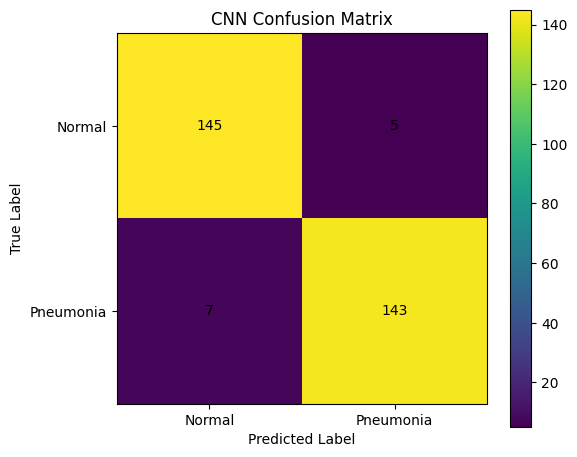

In [18]:


# 1. Generate predictions
# Get probability predictions from the CNN
y_probability = model.predict(
    X_img_test,
    verbose=0
).ravel()

# Convert probabilities into class predictions
# Probability >= 0.5 -> Pneumonia (1)
# Probability < 0.5  -> Normal (0)
y_prediction = (y_probability >= 0.5).astype(int)


# 2. Calculate evaluation metrics

accuracy = accuracy_score(
    y_img_test,
    y_prediction
)

precision = precision_score(
    y_img_test,
    y_prediction,
    zero_division=0
)

recall = recall_score(
    y_img_test,
    y_prediction,
    zero_division=0
)

f1 = f1_score(
    y_img_test,
    y_prediction,
    zero_division=0
)

auroc = roc_auc_score(
    y_img_test,
    y_probability
)


# 3. Display results

print("========== CNN EVALUATION ==========")

print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-Score  :", round(f1, 4))
print("AUROC     :", round(auroc, 4))


# 4. Classification report

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_img_test,
        y_prediction,
        target_names=[
            "Normal",
            "Pneumonia"
        ],
        zero_division=0
    )
)


# 5. Create confusion matrix

cm = confusion_matrix(
    y_img_test,
    y_prediction
)

print("\n========== CONFUSION MATRIX ==========")
print(cm)


# 6. Visualize confusion matrix

plt.figure(figsize=(6, 5))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title("CNN Confusion Matrix")
plt.colorbar()

plt.xticks(
    [0, 1],
    ["Normal", "Pneumonia"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Pneumonia"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Display values inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

Training & Validation Performance

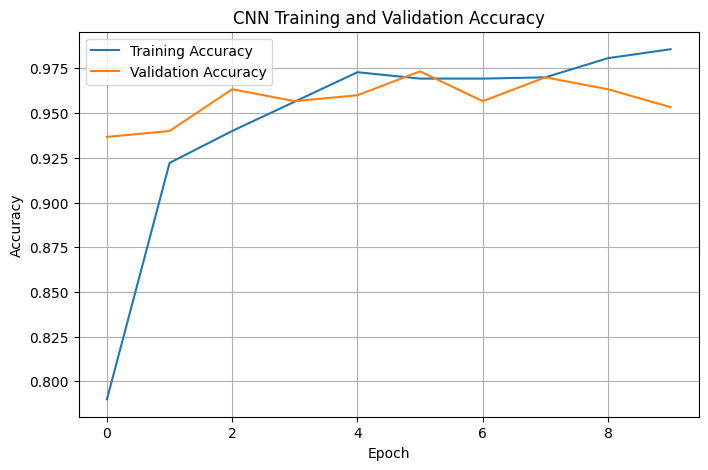

In [19]:

# Create a figure for training and validation accuracy
plt.figure(figsize=(8, 5))

# Plot training accuracy
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

# Plot validation accuracy
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("CNN Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

Misclassification Analysis

Total misclassified images: 12


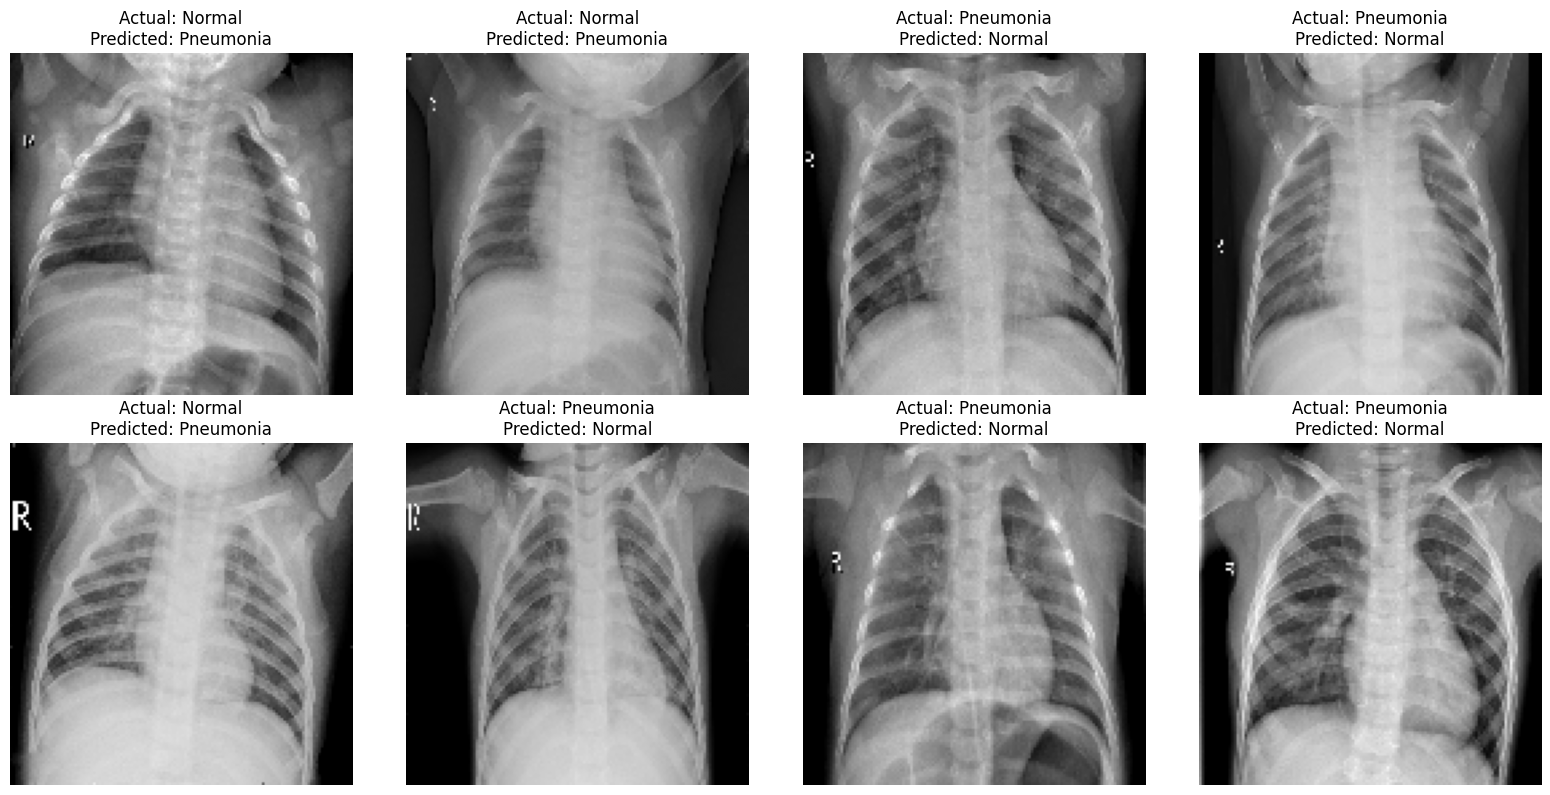

In [20]:


# Find indexes where prediction is incorrect
wrong_indexes = np.where(
    y_prediction != y_img_test
)[0]

print("Total misclassified images:", len(wrong_indexes))

# Display up to 8 incorrectly classified images
num_images = min(8, len(wrong_indexes))

plt.figure(figsize=(16, 8))

for i in range(num_images):

    # Get index of the incorrectly classified image
    index = wrong_indexes[i]

    # Remove the channel dimension for displaying
    image = X_img_test[index].squeeze()

    # Actual and predicted labels
    actual = "Pneumonia" if y_img_test[index] == 1 else "Normal"
    predicted = "Pneumonia" if y_prediction[index] == 1 else "Normal"

    # Display image
    plt.subplot(2, 4, i + 1)

    plt.imshow(image, cmap="gray")

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()